# Company Rating

This is an statistical analysis of a real [database](https://www.kaggle.com/datasets/hardikchoudharyhc/company-reviews-salaries-location-dataset) of company ratings, information was extracted from [AmbitionBox](https://www.ambitionbox.com/reviews) using web scraping.

## Data set load and verification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./../../Datasets/company_reviews.csv")
df.head()

,Name,Rating,Company_type,Reviews,Salaries,Cities
0,TCS,3.3,IT Services & Consulting,1.1L Reviews,9.9L Salaries,Bengaluru
1,Accenture,3.7,IT Services & Consulting,72k Reviews,6.5L Salaries,Bengaluru
2,Wipro,3.6,IT Services & Consulting,63.9k Reviews,4.8L Salaries,Hyderabad
3,Cognizant,3.6,IT Services & Consulting,60.3k Reviews,6L Salaries,Hyderabad
4,Capgemini,3.7,IT Services & Consulting,51.9k Reviews,4.8L Salaries,Bengaluru


Method shape is used to check the number of rows and columns.

In [3]:
df.shape

(9978, 6)

The column Name is checked to look for duplicates

In [4]:
df["Name"].value_counts()

Name
International Travel House                       2
MRL Tyres                                        2
Molbio Diagnostics                               2
Xcaliber Infotech                                2
Aditya Birla SunLife Asset Management Company    2
                                                ..
63 Moons Technologies                            1
MSP Steel & Power                                1
SBI Payment Services                             1
AIMLAY                                           1
Delhi Metro Rail Corporation                     1
Name: count, Length: 9478, dtype: int64

Duplicates are removed

In [5]:
df = df.drop_duplicates("Name",keep="first")
df["Name"].value_counts()

Name
TCS                     1
Accenture               1
Wipro                   1
Cognizant               1
Capgemini               1
                       ..
Brinks Arya India       1
TMI Group               1
Kreate Energy           1
Op Jindal University    1
Rana Sugars             1
Name: count, Length: 9478, dtype: int64

Describe method is applied to check basic statistics on Rating column

In [6]:
df.describe()

,Rating
count,9478.000000
mean,3.737645
std,0.418375
min,1.000000
25%,3.500000
50%,3.800000
75%,4.000000
max,4.900000


## Analysis

### Companies per rating

Companies are analysed based on rating categories with the following ranges: 

- Worst companies: Rating < 2.0
- Bad companies: Rating between 2.0 and 2.9
- Average companies: Rating between 3.0 and 3.9
- Good companies: Rating between 4.0 and 4.5
- Great companies: Rating > 4.5

Data is selected using these ranges creating new tables saved in different variables.

In [7]:
worst_companies = df[df["Rating"] < 2.0]
bad_companies = df[df["Rating"].between(2.0, 2.9)]
avg_companies = df[df["Rating"].between(3.0, 3.9)]
good_companies = df[df["Rating"].between(4.0, 4.5)]
great_companies = df[df["Rating"] > 4.5]

A count of rows is made for every table to know how many companies there are in every category, then a table is created with the amounts

In [8]:
dataframes = [worst_companies, bad_companies, avg_companies, 
              good_companies, great_companies]

counts = []
for df in dataframes:
        shape = df.shape
        size = shape[0]
        counts.append(size)

categories = ["Worst companies", "Bad companies", "Average companies", 
              "Good companies", "Great companies"]

comp_per_rating = pd.DataFrame({"Category": categories,
                                "Amount" : counts})

# A new column is added with the percentage corresponding to each category
total = comp_per_rating["Amount"].sum()
comp_per_rating["Percentage"] = comp_per_rating["Amount"] / total * 100

comp_per_rating

,Category,Amount,Percentage
0,Worst companies,9,0.094957
1,Bad companies,368,3.882676
2,Average companies,6117,64.538932
3,Good companies,2812,29.668706
4,Great companies,172,1.814729


A chart is made to visualize data

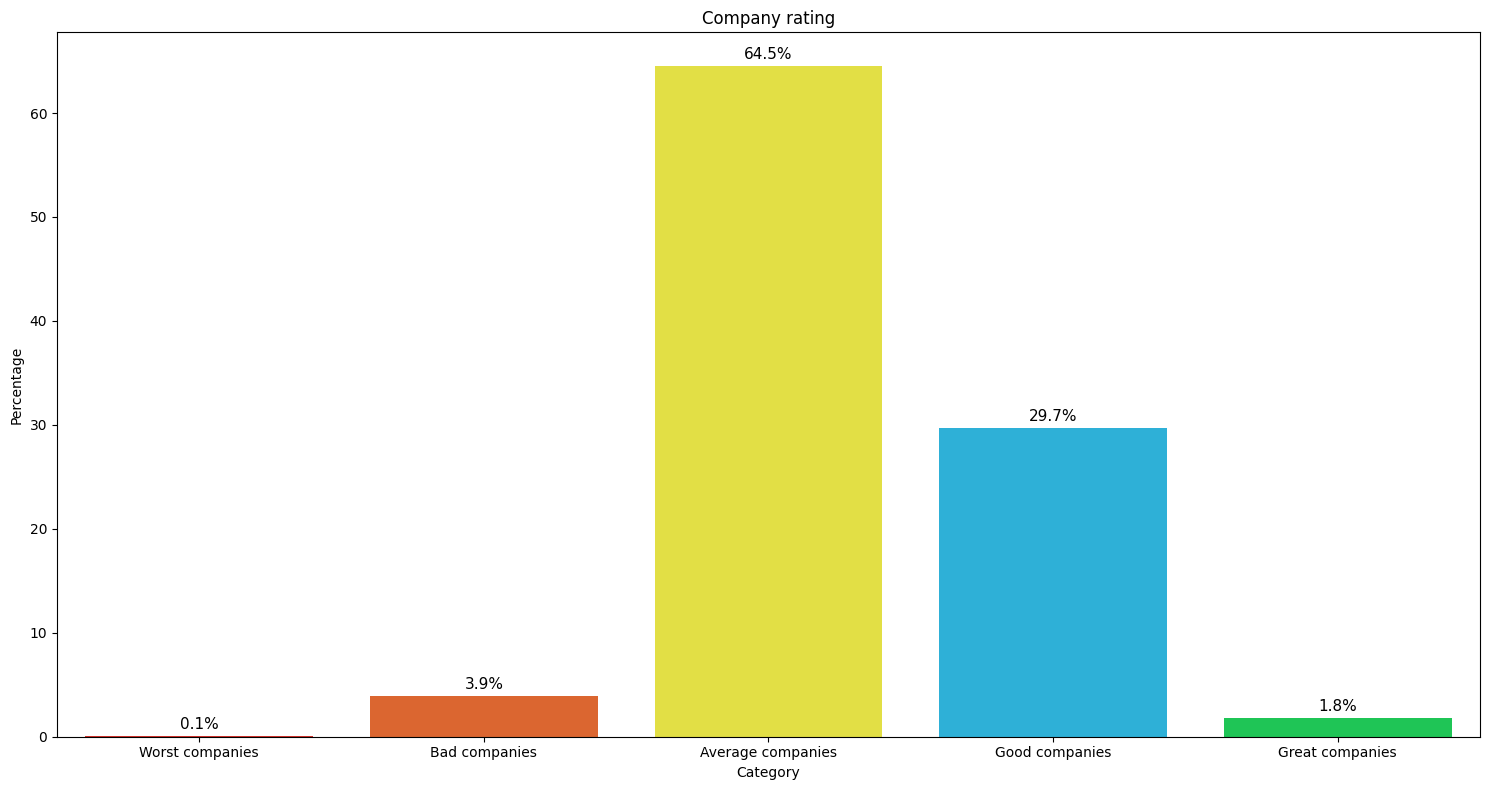

In [9]:
fig = plt.figure(figsize=(15, 8), dpi=100)
ax = fig.gca()

colors = ["#f11810", "#f75c14", "#fcf82b", "#12bff3", "#04e04d"]

sns.barplot(
    data=comp_per_rating,
    x="Category",
    y="Percentage",
    hue="Category",
    palette=colors,
    legend=False,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=11)

ax.set_title("Company rating")
plt.tight_layout()
plt.show()

#### **Best companies**

Companies that have maximum number in Rating are considered the best. 

A new selection is made with this condition and the first five rows are showed.

In [10]:
best_companies = df[df["Rating"] >= 4.9]
best_companies.head()

,Name,Rating,Company_type,Reviews,Salaries,Cities
267,Marpu Foundation,4.9,Non-Profit,3.1k Reviews,60 Salaries,Hyderabad
515,Tekwissen,4.9,IT Services & Consulting,1.9k Reviews,575 Salaries,Visakhapatnam
848,Royal Migration Solutions,4.9,Other,1.2k Reviews,5 Salaries,Dubai
896,Hire In Global,4.9,Recruitment,1.2k Reviews,8 Salaries,Mumbai
1189,Regulated Council of Immigration Consultants,4.9,Other,874 Reviews,-- Salaries,Dubai


### Companies per type

Company_type values are counted to know what are the more frequent categories

In [11]:
df["Company_type"].value_counts()

Company_type
IT Services & Consulting                                 21
Internet                                                 12
Recruitment                                              10
Education & Training                                     10
Software Product                                          9
Real Estate                                               8
Pharma                                                    7
Healthcare                                                6
Financial Services                                        5
EdTech                                                    5
Retail                                                    5
NBFC                                                      5
Defence & Aerospace                                       5
Government                                                4
BPO                                                       4
Industrial Machinery                                      4
Power                      

With this info it can be said that the top 5 company types are the followin:

1. IT Services & Consulting
2. Internet
3. Recruitment
4. Education & Training
5. Software Product